In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import torch
from torch import nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier
from skorch.callbacks import EpochScoring
from skorch.dataset import ValidSplit
from sklearn.metrics import accuracy_score
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint

DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

# Images

In [40]:
# Walid Al-Dhabyani, Mohammed Gomaa, et al., "Dataset of breast ultrasound images," Data in Brief, vol. 28, pp. 104863, 2020.


files = np.load("Data/breastmnist.npz")

train_images = files["train_images"]
train_labels = files["train_labels"]

validation_images = files["val_images"]
validation_labels = files["val_labels"]

test_images = files["test_images"]
test_labels = files["test_labels"]

train_images.shape, train_labels.shape, validation_images.shape, validation_labels.shape, test_images.shape, test_labels.shape

((546, 28, 28), (546, 1), (78, 28, 28), (78, 1), (156, 28, 28), (156, 1))

In [41]:
np.unique(train_labels)

array([0, 1], dtype=uint8)

Text(0.5, 1.0, '[1]')

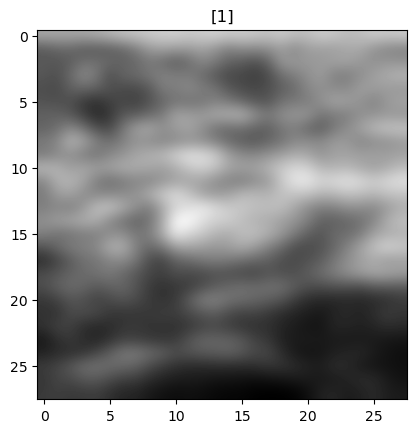

In [42]:
i = 0
plt.imshow(train_images[i], interpolation="bicubic", cmap="gray")
plt.title(train_labels[i])

In [43]:
train_images = train_images.astype(np.float32)[:, None] / 255.0
validation_images = validation_images.astype(np.float32)[:, None] / 255.0
test_images = test_images.astype(np.float32)[:, None] / 255.0
train_labels = train_labels.ravel()
validation_labels = validation_labels.ravel()
test_labels = test_labels.ravel()

train_images.shape, train_labels.shape, validation_images.shape, validation_labels.shape, test_images.shape, test_labels.shape

((546, 1, 28, 28), (546,), (78, 1, 28, 28), (78,), (156, 1, 28, 28), (156,))

In [44]:
# train a dummy classifier
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(train_images, train_labels)
dummy_clf.score(test_images, test_labels)

0.7307692307692307

## 2D Convolutional Autoencoder



In [122]:
# output shape formula for convolutional layers: (W - K + 2P) / S + 1

class Encoder(nn.Module):
    def __init__(self, num_input_channels: int, base_channel_size: int, latent_dim: int, act_fn: object = nn.GELU):
        """Encoder.

        Args:
           num_input_channels : Number of input channels of the image. For CIFAR, this parameter is 3
           base_channel_size : Number of channels we use in the first convolutional layers. Deeper layers might use a duplicate of it.
           latent_dim : Dimensionality of latent representation z
           act_fn : Activation function used throughout the encoder network

        """
        super().__init__()
        c_hid = base_channel_size
        self.net = nn.Sequential(
            nn.Conv2d(num_input_channels, c_hid, kernel_size=3, padding=1, stride=2),  # 28x28 => 14x14
            act_fn(),
            nn.Conv2d(c_hid, c_hid, kernel_size=3, padding=1),
            act_fn(),
            nn.Conv2d(c_hid, 2 * c_hid, kernel_size=3, padding=1, stride=2),  # 14x14 => 7x7
            act_fn(),
            nn.Conv2d(2 * c_hid, 2 * c_hid, kernel_size=3, padding=1),
            act_fn(),
            nn.Conv2d(2 * c_hid, 2 * c_hid, kernel_size=3, padding=1, stride=2),  # 7x7 => 4x4
            act_fn(),  # shape is now (batch_size, 2 * c_hid, 4, 4)
            nn.Flatten(),  # shape is now (batch_size, 2 * 16 * c_hid)
            nn.Linear(2 * 16 * c_hid, latent_dim),
        )

    def forward(self, x):
        return self.net(x)
    

# output shape formula for transposed convolutional layers: (W - 1) * S - 2P + K + output_padding

class Decoder(nn.Module):
    def __init__(self, num_input_channels: int, base_channel_size: int, latent_dim: int, act_fn: object = nn.GELU):
        """Decoder.

        Args:
           num_input_channels : Number of channels of the image to reconstruct. For CIFAR, this parameter is 3
           base_channel_size : Number of channels we use in the last convolutional layers. Early layers might use a duplicate of it.
           latent_dim : Dimensionality of latent representation z
           act_fn : Activation function used throughout the decoder network

        """
        super().__init__()
        c_hid = base_channel_size
        self.linear = nn.Sequential(nn.Linear(latent_dim, 2 * 16 * c_hid), act_fn())
        self.net = nn.Sequential(
            nn.ConvTranspose2d(
                2 * c_hid, 2 * c_hid, kernel_size=3, output_padding=0, padding=1, stride=2
            ),  # 4x4 => 7x7   
            act_fn(),
            nn.Conv2d(2 * c_hid, 2 * c_hid, kernel_size=3, padding=1),
            act_fn(),
            nn.ConvTranspose2d(2 * c_hid, c_hid, kernel_size=3, output_padding=1, padding=1, stride=2),  # 7x7 => 14x14
            act_fn(),
            nn.Conv2d(c_hid, c_hid, kernel_size=3, padding=1),
            act_fn(),
            nn.ConvTranspose2d(
                c_hid, num_input_channels, kernel_size=3, output_padding=1, padding=1, stride=2
            ),  # 14x14 => 28x28
            nn.Sigmoid(),  # The input images is scaled between 0 and 1, hence the output has to be bounded as well
        )

    def forward(self, x):
        x = self.linear(x)
        x = x.reshape(x.shape[0], -1, 4, 4)
        x = self.net(x)
        return x
    
class Autoencoder(nn.Module):
    def __init__(self, num_input_channels: int, base_channel_size: int, latent_dim: int, act_fn: object = nn.GELU):
        """Autoencoder.

        Args:
           num_input_channels : Number of channels of the image to reconstruct. For CIFAR, this parameter is 3
           base_channel_size : Number of channels we use in the convolutional layers. Deeper layers might use a duplicate of it.
           latent_dim : Dimensionality of latent representation z
           act_fn : Activation function used throughout the autoencoder network

        """
        super().__init__()
        self.encoder = Encoder(num_input_channels, base_channel_size, latent_dim, act_fn)
        self.decoder = Decoder(num_input_channels, base_channel_size, latent_dim, act_fn)

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec

In [123]:
validation_images.shape, validation_labels.shape

((78, 1, 28, 28), (78,))

In [124]:
from skorch.helper import predefined_split
from torch.utils.data import TensorDataset

valid_ds = TensorDataset(torch.Tensor(validation_images), torch.Tensor(validation_images))

In [125]:
# wrap the autoencoder in a skorch NeuralNet
from skorch.net import NeuralNet

In [138]:
net = NeuralNet(
    Autoencoder,
    module__num_input_channels=train_images.shape[1],
    module__base_channel_size=256,
    module__latent_dim=16,

    criterion=nn.MSELoss,
    optimizer=torch.optim.Adam,
    max_epochs=50,
    batch_size=32,
    lr=1e-4,

    device=DEVICE,

    train_split=predefined_split(valid_ds)
)
net

<class 'skorch.net.NeuralNet'>[uninitialized](
  module=<class '__main__.Autoencoder'>,
  module__base_channel_size=256,
  module__latent_dim=16,
  module__num_input_channels=1,
)

In [139]:
train_images.shape

(546, 1, 28, 28)

In [140]:
net.fit(train_images, train_images)

  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1        0.0698        0.0399  2.6494
      2        0.0320        0.0298  1.9264
      3        0.0269        0.0232  1.8867
      4        0.0192        0.0158  1.8862
      5        0.0145        0.0133  1.8909
      6        0.0124        0.0119  1.8957
      7        0.0111        0.0107  1.9148
      8        0.0102        0.0099  1.8865
      9        0.0093        0.0090  1.8993
     10        0.0087        0.0085  1.8849
     11        0.0083        0.0082  1.8974
     12        0.0078        0.0078  1.9028
     13        0.0075        0.0076  1.9072
     14        0.0072        0.0074  1.8837
     15        0.0070        0.0073  1.9040
     16        0.0068        0.0072  1.8826
     17        0.0067        0.0070  1.9099
     18        0.0065        0.0069  1.8780
     19        0.0063        0.0068  1.9219
     20        0.0061        0.0066  1.9012
     21        0.0059        0.0

<class 'skorch.net.NeuralNet'>[initialized](
  module_=Autoencoder(
    (encoder): Encoder(
      (net): Sequential(
        (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
        (6): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (7): GELU(approximate='none')
        (8): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (9): GELU(approximate='none')
        (10): Flatten(start_dim=1, end_dim=-1)
        (11): Linear(in_features=8192, out_features=16, bias=True)
      )
    )
    (decoder): Decoder(
      (linear): Sequential(
        (0): Linear(in_features=16, out_features=8192, bias=True)
        (1): GELU(approximate='none')
      )
      (net): Sequential(
        (0): ConvTranspose2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): ConvTranspose2d(512, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
        (5): GELU(approximate='none')
        (6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (7): GELU(approximate='none')
        (8): ConvTranspose2d(256, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
        (9): Sigmoid()
      )
    )
  ),
)

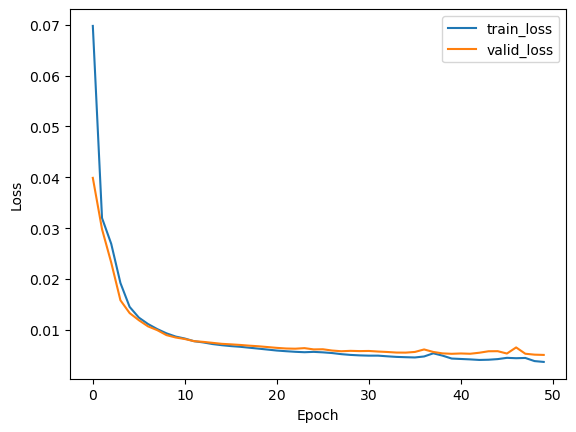

In [141]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [142]:
test_images_recon = net.predict(test_images)
test_images_recon.shape

(156, 1, 28, 28)

Text(0.5, 1.0, 'Reconstructed')

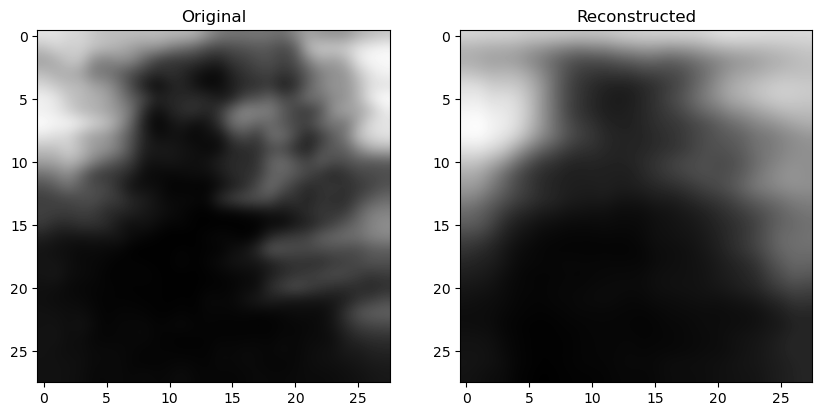

In [144]:
i = 0

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(test_images[i, 0], interpolation="bicubic", cmap="gray")
axs[0].set_title("Original")
axs[1].imshow(test_images_recon[i, 0], interpolation="bicubic", cmap="gray")
axs[1].set_title("Reconstructed")

### Downstream Classification

In [145]:
encoder = net.module_.encoder
encoder.eval()

Encoder(
  (net): Sequential(
    (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): GELU(approximate='none')
    (4): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): GELU(approximate='none')
    (6): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): GELU(approximate='none')
    (8): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): GELU(approximate='none')
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=8192, out_features=16, bias=True)
  )
)

In [147]:
Z_train = encoder(torch.Tensor(train_images).to(DEVICE)).cpu().detach().numpy()
Z_test = encoder(torch.Tensor(test_images).to(DEVICE)).cpu().detach().numpy()
Z_train.shape, Z_test.shape

((546, 16), (156, 16))

In [149]:
# Use PCA to visualize the latent space in 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Z_train_2d = pca.fit_transform(Z_train)
Z_test_2d = pca.transform(Z_test)

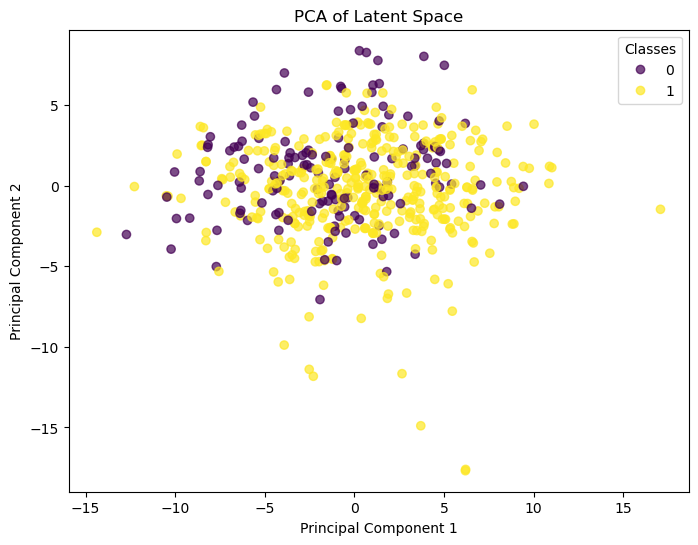

In [151]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(Z_train_2d[:, 0], Z_train_2d[:, 1], c=train_labels, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Latent Space")
plt.show()

In [148]:
# Training a simple classifier on the latent representation
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(Z_train, train_labels)
clf.score(Z_test, test_labels)

0.7948717948717948

# Time Series

### Dataset 

**ECG200**


In [322]:
# Import the dataset
from aeon.datasets import load_classification
X_train, y_train = load_classification("ECG200", split="train")
X_test, y_test = load_classification("ECG200", split="test")
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((100, 1, 96), (100,), (100, 1, 96), (100,))

In [323]:
# Encode the labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
LABELS = le.classes_
le.classes_

array(['-1', '1'], dtype='<U2')

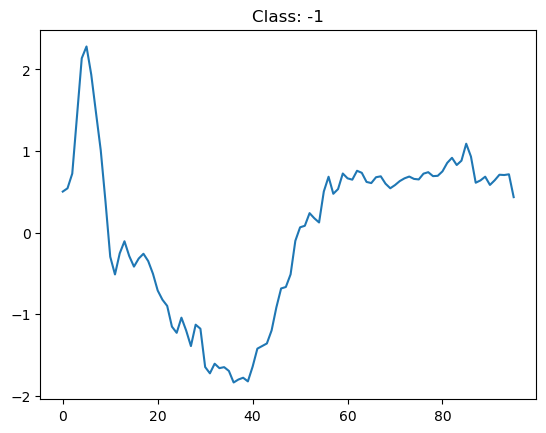

In [324]:
i = 0
plt.plot(X_train[i].ravel())
plt.title(f"Class: {LABELS[y_train[i]]}") 
plt.show()

In [325]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_test, y_test)

0.64

## 1D Convolutional Autoencoder

In [335]:
class Encoder1D(nn.Module):
    def __init__(self, num_input_channels: int, base_channel_size: int, latent_dim: int, act_fn: object = nn.GELU):
        """Encoder.

        Args:
           num_input_channels : Number of input channels of the time series. For univariate time series, this parameter is 1
           base_channel_size : Number of channels we use in the first convolutional layers. Deeper layers might use a duplicate of it.
           latent_dim : Dimensionality of latent representation z
           act_fn : Activation function used throughout the encoder network

        """
        super().__init__()
        c_hid = base_channel_size
        self.net = nn.Sequential(
            nn.Conv1d(num_input_channels, c_hid, kernel_size=3, padding=1, stride=2),  # 96 => 48
            act_fn(),
            nn.Conv1d(c_hid, c_hid, kernel_size=3, padding=1),
            act_fn(),
            nn.Conv1d(c_hid, 2 * c_hid, kernel_size=3, padding=1, stride=2),  # 48 => 24
            act_fn(),
            nn.Conv1d(2 * c_hid, 2 * c_hid, kernel_size=3, padding=1),
            act_fn(),
            nn.Conv1d(2 * c_hid, 2 * c_hid, kernel_size=3, padding=1, stride=2),  # 24 => 12
            act_fn(),  # shape is now (batch_size, 2 * c_hid, 12)
            nn.Flatten(),  # shape is now (batch_size, 2 * 12 * c_hid)
            nn.Linear(2 * 12 * c_hid, latent_dim),
        )

    def forward(self, x):
        return self.net(x)
    

class Decoder1D(nn.Module):
    def __init__(self, num_input_channels: int, base_channel_size: int, latent_dim: int, act_fn: object = nn.GELU):
        """Decoder.

        Args:
           num_input_channels : Number of channels of the time series to reconstruct. For univariate time series, this parameter is 1
           base_channel_size : Number of channels we use in the last convolutional layers. Early layers might use a duplicate of it.
           latent_dim : Dimensionality of latent representation z
           act_fn : Activation function used throughout the decoder network

        """
        super().__init__()
        c_hid = base_channel_size
        self.linear = nn.Sequential(nn.Linear(latent_dim, 2 * 12 * c_hid), act_fn())
        self.net = nn.Sequential(
            nn.ConvTranspose1d(
                2 * c_hid, 2 * c_hid, kernel_size=3, output_padding=1, padding=1, stride=2
            ),  # 12 => 24 
            act_fn(),
            nn.Conv1d(2 * c_hid, 2 * c_hid, kernel_size=3, padding=1),
            act_fn(),
            nn.ConvTranspose1d(2 * c_hid, c_hid, kernel_size=3, output_padding=1, padding=1, stride=2),  # 24 => 48
            act_fn(),
            nn.Conv1d(c_hid, c_hid, kernel_size=3, padding=1),
            act_fn(),
            nn.ConvTranspose1d(
                c_hid, num_input_channels, kernel_size=3, output_padding=1, padding=1, stride=2
            ),  # 48 => 96
        )

    def forward(self, x):
        x = self.linear(x)
        x = x.reshape(x.shape[0], -1, 12)
        x = self.net(x)
        return x
    

class Autoencoder1D(nn.Module):
    def __init__(self, num_input_channels: int, base_channel_size: int, latent_dim: int, act_fn: object = nn.GELU):
        """Autoencoder.

        Args:
           num_input_channels : Number of channels of the time series to reconstruct. For univariate time series, this parameter is 1
           base_channel_size : Number of channels we use in the convolutional layers. Deeper layers might use a duplicate of it.
           latent_dim : Dimensionality of latent representation z
           act_fn : Activation function used throughout the autoencoder network

        """
        super().__init__()
        self.encoder = Encoder1D(num_input_channels, base_channel_size, latent_dim, act_fn)
        self.decoder = Decoder1D(num_input_channels, base_channel_size, latent_dim, act_fn)

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec


In [176]:
net = NeuralNet(
    Autoencoder1D,
    module__num_input_channels=X_train.shape[1],
    module__base_channel_size=128,
    module__latent_dim=2,

    criterion=nn.MSELoss,
    optimizer=torch.optim.Adam,
    max_epochs=50,
    batch_size=32,
    lr=1e-4,

    device=DEVICE,

    train_split=predefined_split(TensorDataset(torch.Tensor(X_test), torch.Tensor(X_test)))
)

In [177]:
net.fit(X_train, X_train)

  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1        1.0997        1.0734  0.1275
      2        1.0628        1.0379  0.0740
      3        1.0257        0.9988  0.0803
      4        0.9823        0.9488  0.0864
      5        0.9237        0.8773  0.0925
      6        0.8366        0.7734  0.0719
      7        0.7122        0.6630  0.0758
      8        0.5857        0.5413  0.0907
      9        0.4475        0.4623  0.0939
     10        0.3837        0.4793  0.0827
     11        0.3902        0.4461  0.0958
     12        0.3655        0.4287  0.0989
     13        0.3530        0.4101  0.0727
     14        0.3354        0.3825  0.0758
     15        0.3098        0.3376  0.0809
     16        0.2714        0.2803  0.0849
     17        0.2256        0.2405  0.0712
     18        0.2065        0.2418  0.0746
     19        0.1992        0.2226  0.0814
     20        0.1807        0.2169  0.0795
     21        0.1743        0.2

<class 'skorch.net.NeuralNet'>[initialized](
  module_=Autoencoder1D(
    (encoder): Encoder1D(
      (net): Sequential(
        (0): Conv1d(1, 128, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): GELU(approximate='none')
        (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (3): GELU(approximate='none')
        (4): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
        (5): GELU(approximate='none')
        (6): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (7): GELU(approximate='none')
        (8): Conv1d(256, 256, kernel_size=(3,), stride=(2,), padding=(1,))
        (9): GELU(approximate='none')
        (10): Flatten(start_dim=1, end_dim=-1)
        (11): Linear(in_features=3072, out_features=2, bias=True)
      )
    )
    (decoder): Decoder1D(
      (linear): Sequential(
        (0): Linear(in_features=2, out_features=3072, bias=True)
        (1): GELU(approximate='none')
      )
      (net): Sequential(
        (0): ConvTranspose1d(256, 256, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
        (1): GELU(approximate='none')
        (2): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (3): GELU(approximate='none')
        (4): ConvTranspose1d(256, 128, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
        (5): GELU(approximate='none')
        (6): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (7): GELU(approximate='none')
        (8): ConvTranspose1d(128, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
      )
    )
  ),
)

In [178]:
X_train_recon = net.predict(X_train)
X_test_recon = net.predict(X_test)

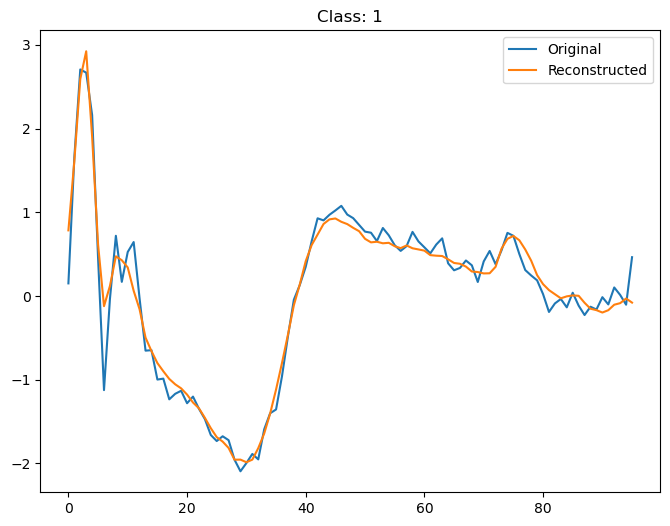

In [182]:
i = 29
plt.figure(figsize=(8, 6))
plt.plot(X_train[i].ravel(), label="Original")
plt.plot(X_train_recon[i].ravel(), label="Reconstructed")
plt.legend()
plt.title(f"Class: {LABELS[y_train[i]]}")
plt.show()

In [183]:
encoder = net.module_.encoder
encoder

Encoder1D(
  (net): Sequential(
    (0): Conv1d(1, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): GELU(approximate='none')
    (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): GELU(approximate='none')
    (4): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): GELU(approximate='none')
    (6): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): GELU(approximate='none')
    (8): Conv1d(256, 256, kernel_size=(3,), stride=(2,), padding=(1,))
    (9): GELU(approximate='none')
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=3072, out_features=2, bias=True)
  )
)

In [185]:
Z_train = encoder(torch.Tensor(X_train).to(DEVICE)).cpu().detach().numpy()
Z_test = encoder(torch.Tensor(X_test).to(DEVICE)).cpu().detach().numpy()
Z_train.shape, Z_test.shape

((100, 2), (100, 2))

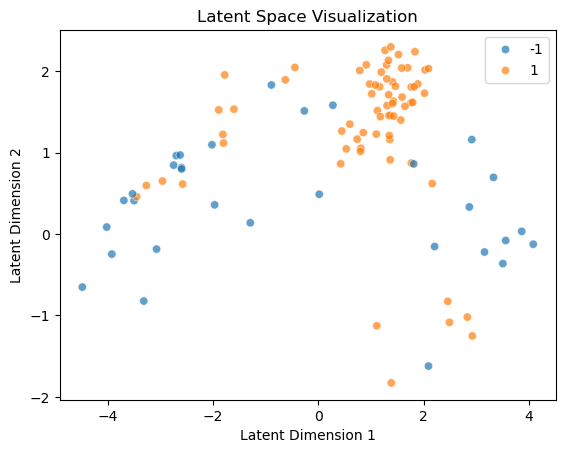

In [194]:
# visualize the latent space
import seaborn as sns

sns.scatterplot(x=Z_train[:, 0], y=Z_train[:, 1], hue=le.classes_[y_train], alpha=0.7)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Latent Space Visualization")
plt.show()

In [195]:
# training a downstream classifier on the latent representation
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(Z_train, y_train)
clf.score(Z_test, y_test)

0.75

### Variational Autoencoder

In [405]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class VariationalEncoder1D(nn.Module):
    def __init__(
        self,
        num_input_channels: int,
        base_channel_size: int,
        latent_dim: int,
        act_fn: object = nn.GELU,
    ):
        super().__init__()
        c_hid = base_channel_size

        self.net = nn.Sequential(
            nn.Conv1d(num_input_channels, c_hid, kernel_size=3, padding=1, stride=2),  # 96 => 48
            act_fn(),
            nn.Conv1d(c_hid, c_hid, kernel_size=3, padding=1),
            act_fn(),

            nn.Conv1d(c_hid, 2 * c_hid, kernel_size=3, padding=1, stride=2),  # 48 => 24
            act_fn(),
            nn.Conv1d(2 * c_hid, 2 * c_hid, kernel_size=3, padding=1),
            act_fn(),

            nn.Conv1d(2 * c_hid, 2 * c_hid, kernel_size=3, padding=1, stride=2),  # 24 => 12
            act_fn(),

            nn.Flatten(),
        )

        self.fc_mu = nn.Linear(2 * 12 * c_hid, latent_dim)
        self.fc_logvar = nn.Linear(2 * 12 * c_hid, latent_dim)

    def forward(self, x):
        h = self.net(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    

class VAE1D(nn.Module):
    def __init__(
        self,
        num_input_channels: int,
        base_channel_size: int,
        latent_dim: int,
        act_fn: object = nn.GELU,
    ):
        super().__init__()
        self.encoder = VariationalEncoder1D(
            num_input_channels=num_input_channels,
            base_channel_size=base_channel_size,
            latent_dim=latent_dim,
            act_fn=act_fn,
        )

        self.decoder = Decoder1D(
            num_input_channels=num_input_channels,
            base_channel_size=base_channel_size,
            latent_dim=latent_dim,
            act_fn=act_fn,
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_rec = self.decoder(z)
        return x_rec, mu, logvar, z
    

class VAELoss(nn.Module):
    def __init__(self, beta: float = 1.0, reduction: str = "mean"):
        super().__init__()
        self.beta = beta
        self.reduction = reduction

    def forward(self, output, target):
        x_rec, mu, logvar, z = output

        rec_loss = F.mse_loss(x_rec, target, reduction=self.reduction)

        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1,
        )

        if self.reduction == "mean":
            kl_loss = kl_loss.mean()
        elif self.reduction == "sum":
            kl_loss = kl_loss.sum()

        return rec_loss + self.beta * kl_loss
    

In [ ]:
from skorch import NeuralNet
from skorch.helper import predefined_split
import torch

net = NeuralNet(
    VAE1D,
    module__num_input_channels=X_train.shape[1],
    module__base_channel_size=128,
    module__latent_dim=2,

    criterion=VAELoss,
    criterion__beta=0.001,

    optimizer=torch.optim.Adam,
    max_epochs=100,
    batch_size=32,
    lr=1e-3,

    device=DEVICE,
)

In [414]:
net.fit(X_train, X_train)

  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1        1.0199        0.8457  0.0679
      2        0.7492        0.5270  0.0517
      3        0.4887        0.5744  0.0536
      4        0.5361        0.4734  0.0551
      5        0.4440        0.4460  0.0556
      6        0.4064        0.4836  0.0603
      7        0.3878        0.4572  0.0716
      8        0.3613        0.4316  0.0504
      9        0.3583        0.4053  0.0516
     10        0.3540        0.4094  0.0519
     11        0.3451        0.3968  0.0581
     12        0.3210        0.3745  0.0493
     13        0.2733        0.2747  0.0519
     14        0.2283        0.2197  0.0545
     15        0.1892        0.1643  0.0617
     16        0.1629        0.1510  0.0619
     17        0.1555        0.1469  0.0607
     18        0.1402        0.1452  0.0595
     19        0.1326        0.1349  0.0624
     20        0.1308        0.1355  0.0687
     21        0.1272        0.1

<class 'skorch.net.NeuralNet'>[initialized](
  module_=VAE1D(
    (encoder): VariationalEncoder1D(
      (net): Sequential(
        (0): Conv1d(1, 128, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): GELU(approximate='none')
        (2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (3): GELU(approximate='none')
        (4): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
        (5): GELU(approximate='none')
        (6): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (7): GELU(approximate='none')
        (8): Conv1d(256, 256, kernel_size=(3,), stride=(2,), padding=(1,))
        (9): GELU(approximate='none')
        (10): Flatten(start_dim=1, end_dim=-1)
      )
      (fc_mu): Linear(in_features=3072, out_features=2, bias=True)
      (fc_logvar): Linear(in_features=3072, out_features=2, bias=True)
    )
    (decoder): Decoder1D(
      (linear): Sequential(
        (0): Linear(in_features=2, out_features=3072, bias=True)
        (1): GELU(approximate='none')
      )
      (net): Sequential(
        (0): ConvTranspose1d(256, 256, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
        (1): GELU(approximate='none')
        (2): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (3): GELU(approximate='none')
        (4): ConvTranspose1d(256, 128, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
        (5): GELU(approximate='none')
        (6): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (7): GELU(approximate='none')
        (8): ConvTranspose1d(128, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
      )
    )
  ),
)

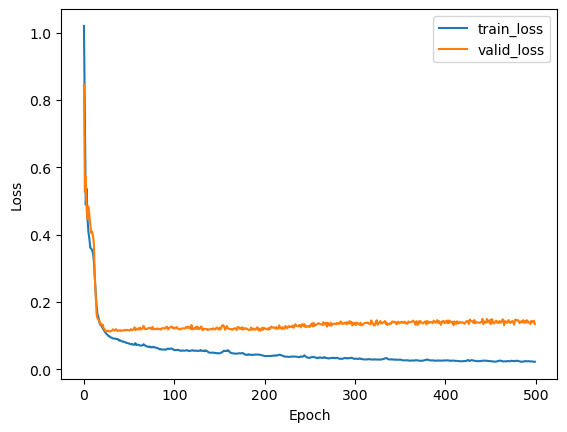

In [415]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [416]:
X_train_recon = net.predict(X_train)
X_test_recon = net.predict(X_test)

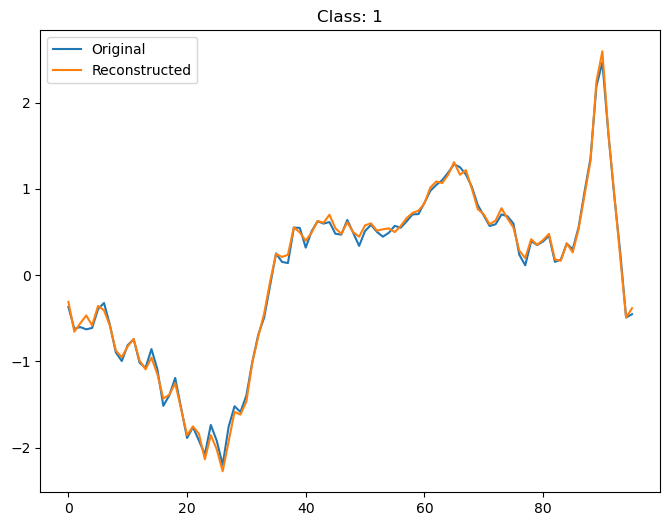

In [424]:
i = 20
plt.figure(figsize=(8, 6))
plt.plot(X_train[i].ravel(), label="Original")
plt.plot(X_train_recon[i].ravel(), label="Reconstructed")
plt.legend()
plt.title(f"Class: {LABELS[y_train[i]]}")
plt.show()

In [418]:
vae = net.module_
vae.eval()

with torch.no_grad():
    mu_train, logvar_train = vae.encoder(torch.tensor(X_train, dtype=torch.float32).to(DEVICE))

with torch.no_grad():
    mu_test, logvar_test = vae.encoder(torch.tensor(X_test, dtype=torch.float32).to(DEVICE))

Z_train = mu_train.cpu().numpy()
Z_test = mu_test.cpu().numpy()

In [419]:
# downstream classification on the latent representation
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(Z_train, y_train)
clf.score(Z_test, y_test)

0.79

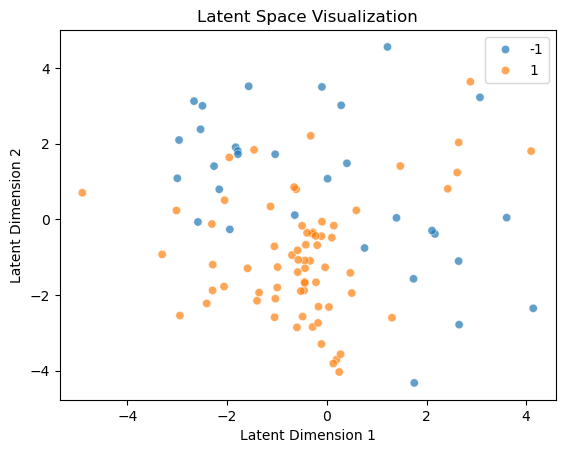

In [420]:
sns.scatterplot(x=Z_train[:, 0], y=Z_train[:, 1], hue=le.classes_[y_train], alpha=0.7)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Latent Space Visualization")
plt.show()

In [452]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.tree import DecisionTreeClassifier

# Fit classifier on latent representation
clf = DecisionTreeClassifier(random_state=0)
clf.fit(Z_train, y_train)

print("test score:", clf.score(Z_test, y_test))

vae = net.module_
vae.eval()

latent_dim = 2
n_grid = 10

# Gaussian quantile grid
q = np.linspace(0.001, 0.999, n_grid)
z_vals = norm.ppf(q)

zz1, zz2 = np.meshgrid(z_vals, z_vals)

Z_grid = np.stack(
    [zz1.ravel(), zz2.ravel()],
    axis=1,
)

# Predict class at each latent grid point
y_grid_pred = clf.predict(Z_grid)

Z_grid_tensor = torch.tensor(Z_grid, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    X_grid = vae.decoder(Z_grid_tensor)

X_grid = X_grid.cpu().numpy()

test score: 0.79


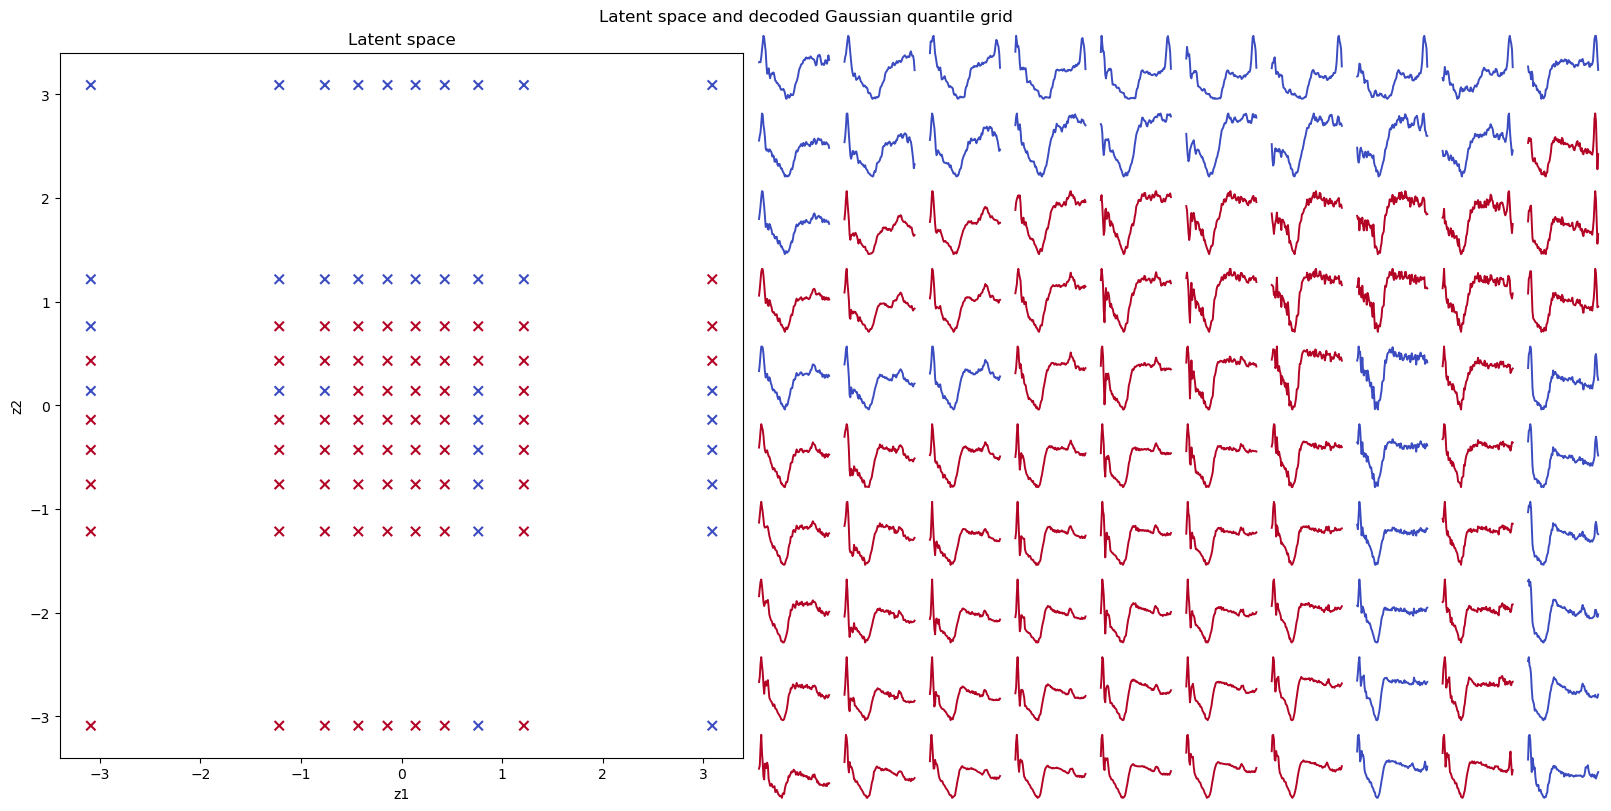

In [453]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

classes = np.unique(y_train)
cmap = plt.get_cmap("coolwarm", len(classes))

class_to_color_idx = {cls: k for k, cls in enumerate(classes)}

fig = plt.figure(figsize=(16, 8), constrained_layout=True)

outer = GridSpec(
    1,
    2,
    figure=fig,
    width_ratios=[1, 1.25],
)

# Left: latent scatter
ax_scatter = fig.add_subplot(outer[0, 0])

scatter_colors = [class_to_color_idx[y] for y in y_train]

# sc = ax_scatter.scatter(
#     Z_train[:, 0],
#     Z_train[:, 1],
#     c=scatter_colors,
#     cmap=cmap,
#     s=25,
#     alpha=0.8,
# )

ax_scatter.scatter(
    Z_grid[:, 0],
    Z_grid[:, 1],
    c=[class_to_color_idx[y] for y in y_grid_pred],
    cmap=cmap,
    marker="x",
    s=45,
)

ax_scatter.set_xlabel("z1")
ax_scatter.set_ylabel("z2")
ax_scatter.set_title("Latent space")


# Right: decoded grid
inner = GridSpecFromSubplotSpec(
    n_grid,
    n_grid,
    subplot_spec=outer[0, 1],
    wspace=0.05,
    hspace=0.05,
)

for i in range(n_grid):
    for j in range(n_grid):
        idx = i * n_grid + j

        # This orientation matches the scatter:
        # low z2 at the bottom, high z2 at the top.
        ax = fig.add_subplot(inner[n_grid - 1 - i, j])

        pred_class = y_grid_pred[idx]
        color_idx = class_to_color_idx[pred_class]
        color = cmap(color_idx)

        ax.plot(X_grid[idx, 0], color=color, linewidth=1.4)

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_facecolor("none")

fig.suptitle("Latent space and decoded Gaussian quantile grid")

plt.show()

## Exercises
- Build a standard autoencoder for the Heartbeat dataset
- Try to use it for classification
- Build a variational autoencoder for the same dataset

In [ ]:
# Import the dataset
X_train, y_train = load_classification("Heartbeat", split="train")
X_test, y_test = load_classification("Heartbeat", split="test")
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((204, 61, 405), (204,), (205, 61, 405), (205,))

In [ ]:
# Encode the labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
LABELS = le.classes_
le.classes_

array(['abnormal', 'normal'], dtype='<U8')

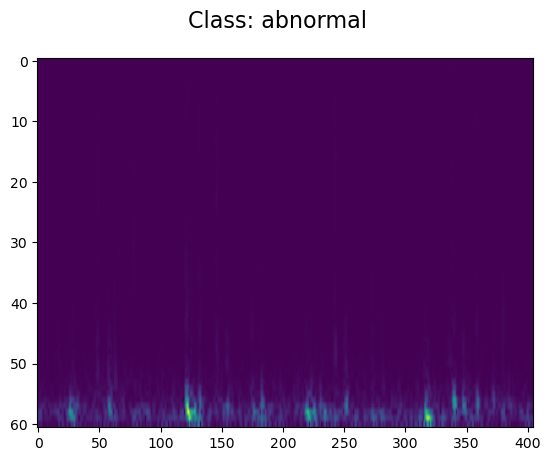

In [ ]:
i = 100
plt.imshow(X_train[i], aspect='auto', cmap='viridis')
plt.suptitle('Class: {}'.format(LABELS[y_train[i]]), fontsize=16)
plt.show()

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_test, y_test)

0.7219512195121951